# VQA với CLIP Attention Model

Notebook này thực hiện training và evaluation cho mô hình Visual Question Answering sử dụng CLIP encoders với attention mechanism.

## Kiến trúc mô hình:
1. Raw Image + Question → CLIP Visual Encoder + CLIP Text Encoder
2. Compute Similarity Score → Use Similarity to Guide Attention  
3. Apply Attention to Visual Features → Combine with Question Features
4. Final Classification

In [1]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
import os
from tqdm import tqdm
import warnings
import requests
from io import BytesIO
warnings.filterwarnings('ignore')

# Import custom modules
from model import CLIPVQAModel
from dataset import create_dataloaders, load_image_from_url, predict_single_image
from train import train_model, evaluate_model, plot_training_history, load_best_model
from visualization import visualize_attention, analyze_predictions, demo_predictions

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported successfully!
PyTorch version: 2.7.1+cu126
CUDA available: True
GPU: Quadro P1000


In [2]:
# Setup Configuration
DATA_DIR = "data"
TRAIN_JSON = os.path.join(DATA_DIR, "Annotations", "train.json")
VAL_JSON = os.path.join(DATA_DIR, "Annotations", "val.json")
TEST_JSON = os.path.join(DATA_DIR, "Annotations", "test.json")

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train")
VAL_IMG_DIR = os.path.join(DATA_DIR, "val")
TEST_IMG_DIR = os.path.join(DATA_DIR, "test")

# Training configuration
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 15
MAX_ANSWERS = 1000
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Check data files
print("\nChecking data files...")
for file_path in [TRAIN_JSON, VAL_JSON, TEST_JSON]:
    if os.path.exists(file_path):
        print(f"✓ Found: {file_path}")
    else:
        print(f"✗ Missing: {file_path}")

# Create directories
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

Using device: cuda

Checking data files...
✓ Found: data\Annotations\train.json
✓ Found: data\Annotations\val.json
✓ Found: data\Annotations\test.json


In [3]:
# Initialize CLIP Processor
print("Loading CLIP processor...")
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

# Load and examine sample data
print("\nLoading sample data...")
with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"Number of training samples: {len(train_data)}")

# Show sample annotation
print("\nSample training annotation:")
sample = train_data[0]
print(f"Image: {sample['image']}")
print(f"Question: {sample['question']}")
print(f"Answers: {[ans['answer'] for ans in sample['answers'][:3]]}...")

# Count answer distribution
answer_counts = {}
for item in train_data[:10000]:  # Sample subset for analysis
    if 'answers' in item:
        for answer_obj in item['answers']:
            answer = answer_obj['answer'].lower().strip()
            answer_counts[answer] = answer_counts.get(answer, 0) + 1

# Show most common answers
top_answers = sorted(answer_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 most common answers:")
for answer, count in top_answers:
    print(f"  {answer}: {count}")

print(f"\nTotal unique answers in sample: {len(answer_counts)}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading CLIP processor...

Loading sample data...
Number of training samples: 18471

Sample training annotation:
Image: VizWiz_train_00002052.jpg
Question: What is this?
Answers: ['keyboard', 'keyboard', 'windows button']...

Top 10 most common answers:
  unanswerable: 27021
  no: 2475
  yes: 2088
  white: 1242
  grey: 1140
  black: 1005
  blue: 902
  red: 615
  brown: 442
  green: 404

Total unique answers in sample: 22469


In [4]:
# Test JSON file encoding
print("Testing JSON file encoding with multiple encodings...")

def test_json_encoding(file_path):
    """Test JSON file with multiple encodings"""
    encodings = ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding) as f:
                data = json.load(f)
            print(f"  ✓ Successfully loaded with {encoding} - {len(data)} samples")
            return True, encoding
        except UnicodeDecodeError:
            print(f"  ✗ Failed with {encoding}")
            continue
        except Exception as e:
            print(f"  ✗ Error with {encoding}: {e}")
            continue
    
    return False, None

json_files = [
    ("Train", TRAIN_JSON),
    ("Validation", VAL_JSON), 
    ("Test", TEST_JSON)
]

for name, json_path in json_files:
    print(f"\nTesting {name} file: {json_path}")
    if os.path.exists(json_path):
        success, encoding = test_json_encoding(json_path)
        if success:
            print(f"  ✓ {name} file can be loaded with {encoding}")
        else:
            print(f"  ✗ {name} file cannot be loaded with any encoding")
    else:
        print(f"  ✗ {name} file not found")

print("\nJSON encoding test completed.")

Testing JSON file encoding with multiple encodings...

Testing Train file: data\Annotations\train.json
  ✓ Successfully loaded with utf-8 - 18471 samples
  ✓ Train file can be loaded with utf-8

Testing Validation file: data\Annotations\val.json
  ✓ Successfully loaded with utf-8 - 2052 samples
  ✓ Validation file can be loaded with utf-8

Testing Test file: data\Annotations\test.json
  ✓ Successfully loaded with utf-8 - 4319 samples
  ✓ Test file can be loaded with utf-8

JSON encoding test completed.


In [5]:
# Create Data Loaders
print("Creating data loaders...")

try:
    train_loader, val_loader, test_loader, num_classes = create_dataloaders(
        train_json=TRAIN_JSON,
        val_json=VAL_JSON,
        test_json=TEST_JSON,
        train_dir=TRAIN_IMG_DIR,
        val_dir=VAL_IMG_DIR,
        test_dir=TEST_IMG_DIR,
        processor=processor,
        batch_size=BATCH_SIZE,
        max_answers=MAX_ANSWERS
    )
    
    print(f"✓ Data loaders created successfully!")
    print(f"Number of classes: {num_classes}")
    print(f"Training batches: {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")
    print(f"Test batches: {len(test_loader)}")
    
    # Get sample batch
    sample_batch = next(iter(train_loader))
    print(f"\nSample batch shapes:")
    print(f"Images: {sample_batch['pixel_values'].shape}")
    print(f"Labels: {sample_batch['labels'].shape}")
    print(f"Questions: {len(sample_batch['questions'])}")
    
    # Show sample questions
    print(f"\nSample questions:")
    for i, q in enumerate(sample_batch['questions'][:3]):
        print(f"  {i+1}. {q}")
        
except Exception as e:
    print(f"Error creating data loaders: {e}")
    print("Please check data paths and files.")

Creating data loaders...
Creating training dataset...
Loading dataset from: data\Annotations\train.json
  Trying encoding: utf-8
  ✓ Successfully loaded with utf-8
Creating validation dataset...
Loading dataset from: data\Annotations\val.json
  Trying encoding: utf-8
  ✓ Successfully loaded with utf-8
Creating test dataset...
Loading dataset from: data\Annotations\test.json
  Trying encoding: utf-8
  ✓ Successfully loaded with utf-8
Aligning vocabularies...
Creating data loaders...
✓ Data loaders created successfully!
Number of classes: 1000
Training batches: 1155
Validation batches: 129
Test batches: 270

Sample batch shapes:
Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Questions: 16

Sample questions:
  1. What is this?
  2. Can you tell me the name of that CD please?
  3. What's this photo?


In [6]:
# Initialize VQA Model
print("Initializing VQA model with CLIP attention...")

model = CLIPVQAModel(
    num_classes=num_classes,
    clip_model_name=CLIP_MODEL_NAME
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model initialized successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Model architecture summary
print(f"\nModel components:")
print(f"- CLIP Visual Encoder: {model.vision_dim} features")
print(f"- CLIP Text Encoder: {model.text_dim} features")
print(f"- Attention mechanism: Similarity-guided")
print(f"- Classifier: {num_classes} classes")

# Test forward pass
print(f"\nTesting forward pass...")
try:
    with torch.no_grad():
        sample_images = sample_batch['pixel_values'][:2].to(device)
        sample_questions = sample_batch['questions'][:2]
        
        logits, attention_weights = model(sample_images, sample_questions)
        
        print(f"✓ Forward pass successful!")
        print(f"Logits shape: {logits.shape}")
        print(f"Attention weights shape: {attention_weights.shape}")
        
except Exception as e:
    print(f"✗ Forward pass failed: {e}")

Initializing VQA model with CLIP attention...
✓ Model initialized successfully!
Total parameters: 153,306,090
Trainable parameters: 2,028,777
Frozen parameters: 151,277,313

Model components:
- CLIP Visual Encoder: 768 features
- CLIP Text Encoder: 512 features
- Attention mechanism: Similarity-guided
- Classifier: 1000 classes

Testing forward pass...
✓ Forward pass successful!
Logits shape: torch.Size([2, 1000])
Attention weights shape: torch.Size([2, 50])


Starting training...

Epoch 1/15


Training:   0%|          | 0/1155 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 129/129 [01:43<00:00,  1.25it/s]


Train Loss: 3.7678, Train Acc: 48.58%
Val Loss: 3.2434, Val Acc: 51.69%
New best model saved with val acc: 51.69%

Epoch 2/15


Evaluating: 100%|██████████| 129/129 [01:29<00:00,  1.44it/s]


...

Train Loss: 2.3667, Train Acc: 53.43%
Val Loss: 2.6087, Val Acc: 54.45%

Epoch 14/15


Evaluating: 100%|██████████| 129/129 [03:17<00:00,  1.53s/it]


Train Loss: 2.3039, Train Acc: 53.76%
Val Loss: 2.5878, Val Acc: 54.99%
New best model saved with val acc: 54.99%

Epoch 15/15


Evaluating: 100%|██████████| 129/129 [01:55<00:00,  1.11it/s]


Train Loss: 2.2369, Train Acc: 53.87%
Val Loss: 2.5901, Val Acc: 54.79%
✓ Training completed successfully!
Best validation accuracy: 54.99%


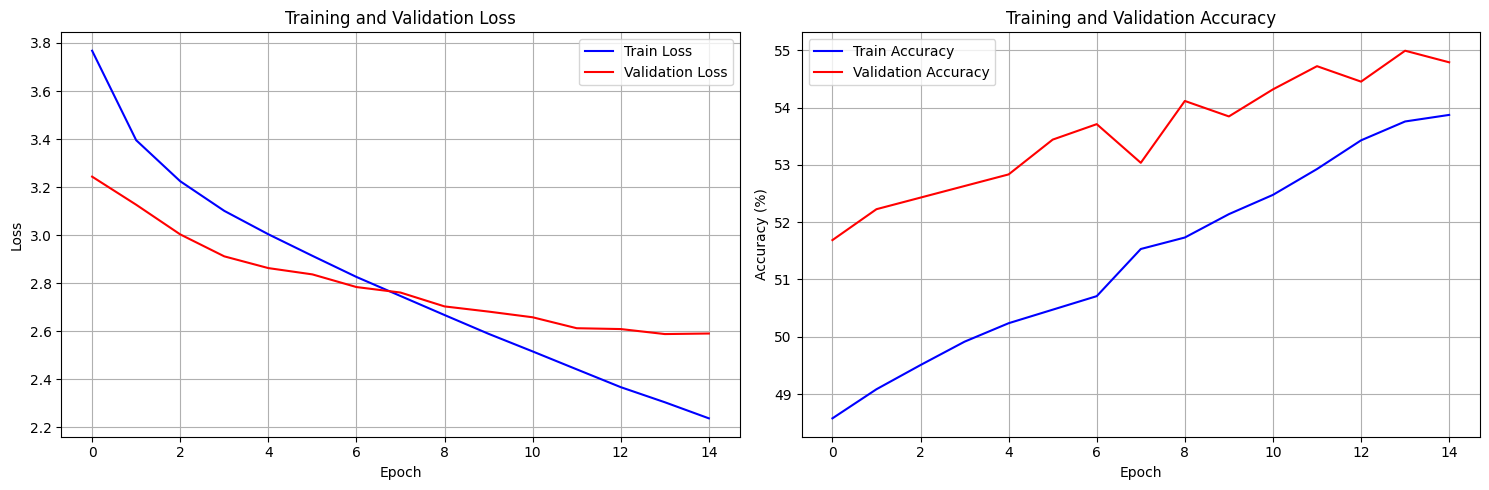

In [8]:
# Training Loop
print("Starting training...")
print("=" * 50)

try:
    # Train the model
    training_history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device,
        save_dir='checkpoints'
    )
    
    print("✓ Training completed successfully!")
    print(f"Best validation accuracy: {training_history['best_val_acc']:.2f}%")
    
    # Plot training history
    plot_training_history(training_history)
    
except Exception as e:
    print(f"✗ Training failed: {e}")
    import traceback
    traceback.print_exc()

In [9]:
# Load Best Model and Evaluate
print("Loading best model and evaluating...")

try:
    # Load best model
    model = load_best_model(model, 'checkpoints/best_model.pth')
    model.to(device)
    
    # Evaluate on validation set
    print("\nEvaluating on validation set...")
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
    print(f"Validation - Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%")
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)
    print(f"Test - Loss: {test_loss:.4f}, Accuracy: {test_acc:.2f}%")
    
    # Save results
    results = {
        'val_loss': val_loss,
        'val_accuracy': val_acc,
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'training_history': training_history
    }
    
    torch.save(results, 'results/evaluation_results.pth')
    print("✓ Results saved to results/evaluation_results.pth")
    
except Exception as e:
    print(f"✗ Evaluation failed: {e}")
    import traceback
    traceback.print_exc()

Loading best model and evaluating...
Loaded model from epoch 13 with val acc: 54.99%

Evaluating on validation set...


Evaluating: 100%|██████████| 129/129 [01:35<00:00,  1.35it/s]


Validation - Loss: 2.5878, Accuracy: 54.99%

Evaluating on test set...


Evaluating: 100%|██████████| 270/270 [04:50<00:00,  1.08s/it]

Test - Loss: 2.2474, Accuracy: 61.23%
✓ Results saved to results/evaluation_results.pth


In [10]:
# Detailed Prediction Analysis
print("Performing detailed prediction analysis...")

try:
    # Get vocabulary mapping from training dataset
    train_dataset = train_loader.dataset
    idx_to_answer = train_dataset.idx_to_answer
    
    # Analyze validation predictions
    print("\n" + "="*50)
    print("VALIDATION SET ANALYSIS")
    print("="*50)
    val_analysis = analyze_predictions(
        model=model,
        data_loader=val_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=500
    )
    
    # Analyze test predictions
    print("\n" + "="*50)
    print("TEST SET ANALYSIS")
    print("="*50)
    test_analysis = analyze_predictions(
        model=model,
        data_loader=test_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=200
    )
    
    print("✓ Prediction analysis completed!")
    
except Exception as e:
    print(f"✗ Analysis failed: {e}")
    import traceback
    traceback.print_exc()

Performing detailed prediction analysis...

VALIDATION SET ANALYSIS
Analysis Results (n=506):
Accuracy: 0.5909
Average Confidence: 0.5427
Confidence Std: 0.2682

Sample Predictions:
✗ Q: Can you tell me what is in this can please?
   Predicted: unanswerable (conf: 0.335)
   True: coca cola

✗ Q: Is this enchilada sauce or is this tomatoes?  Thank you.
   Predicted: unanswerable (conf: 0.125)
   True: tomatoes

✗ Q: What's this?
   Predicted: shoe (conf: 0.257)
   True: shoes

✗ Q: What is in this bottle?
   Predicted: unanswerable (conf: 0.191)
   True: mouthwash

✗ Q: What color do these look?
   Predicted: unanswerable (conf: 0.547)
   True: orange


TEST SET ANALYSIS
Analysis Results (n=205):
Accuracy: 0.7854
Average Confidence: 0.7112
Confidence Std: 0.2106

Sample Predictions:
✓ Q: Ok. There is another picture I hope it is a better one.
   Predicted: unanswerable (conf: 0.825)
   True: unanswerable

✗ Q: Which one is the blue one?
   Predicted: unanswerable (conf: 0.652)
   True: 

Creating result visualizations...
Plotting confidence distributions...


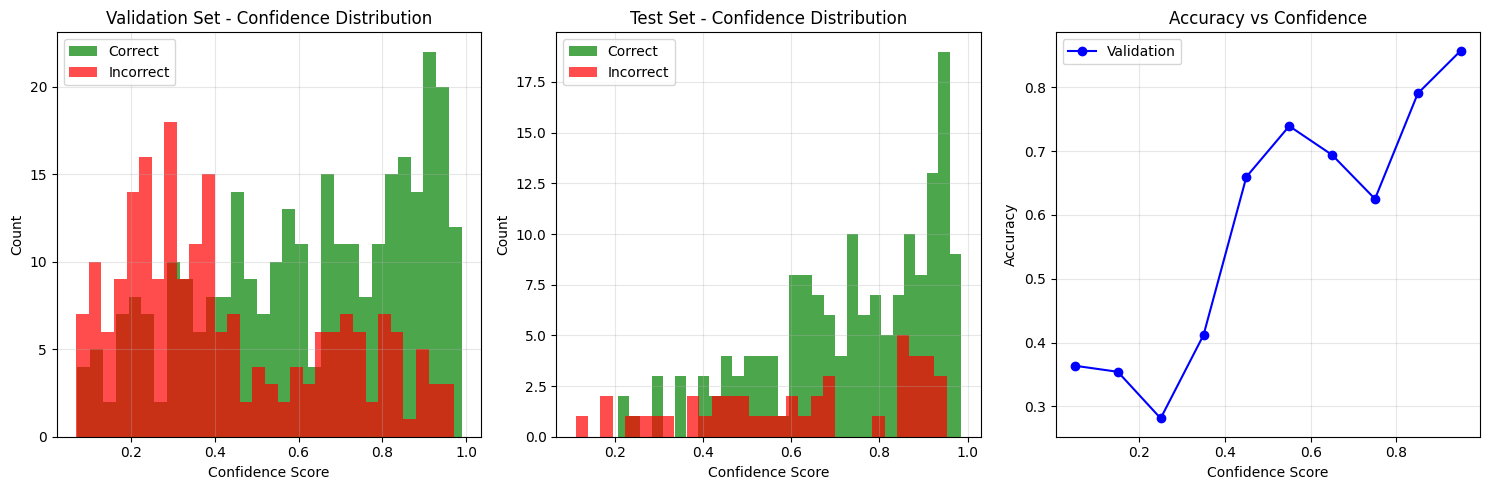

✓ Confidence analysis plots created!


In [11]:
# Results Visualization
print("Creating result visualizations...")

try:
    # Plot confidence distribution
    print("Plotting confidence distributions...")
    
    # Validation set confidence
    val_correct = val_analysis['predictions'] == val_analysis['labels']
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(val_analysis['confidences'][val_correct], bins=30, alpha=0.7, 
             label='Correct', color='green')
    plt.hist(val_analysis['confidences'][~val_correct], bins=30, alpha=0.7, 
             label='Incorrect', color='red')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Validation Set - Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Test set confidence
    test_correct = test_analysis['predictions'] == test_analysis['labels']
    
    plt.subplot(1, 3, 2)
    plt.hist(test_analysis['confidences'][test_correct], bins=30, alpha=0.7, 
             label='Correct', color='green')
    plt.hist(test_analysis['confidences'][~test_correct], bins=30, alpha=0.7, 
             label='Incorrect', color='red')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Test Set - Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs confidence
    plt.subplot(1, 3, 3)
    conf_bins = np.linspace(0, 1, 11)
    bin_centers = (conf_bins[:-1] + conf_bins[1:]) / 2
    
    val_accuracies = []
    for i in range(len(conf_bins)-1):
        mask = (val_analysis['confidences'] >= conf_bins[i]) & \
               (val_analysis['confidences'] < conf_bins[i+1])
        if mask.sum() > 0:
            acc = (val_analysis['predictions'][mask] == val_analysis['labels'][mask]).mean()
            val_accuracies.append(acc)
        else:
            val_accuracies.append(0)
    
    plt.plot(bin_centers, val_accuracies, 'o-', label='Validation', color='blue')
    plt.xlabel('Confidence Score')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Confidence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/confidence_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Confidence analysis plots created!")
    
except Exception as e:
    print(f"✗ Visualization failed: {e}")
    import traceback
    traceback.print_exc()

Demo with sample images from URLs...
Running demo with 4 examples...
Demo Predictions:
Example 1:
Question: What animal is this?
Predicted Answer: cat
Confidence: 0.173
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7
Example 1:
Question: What animal is this?
Predicted Answer: cat
Confidence: 0.173
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7


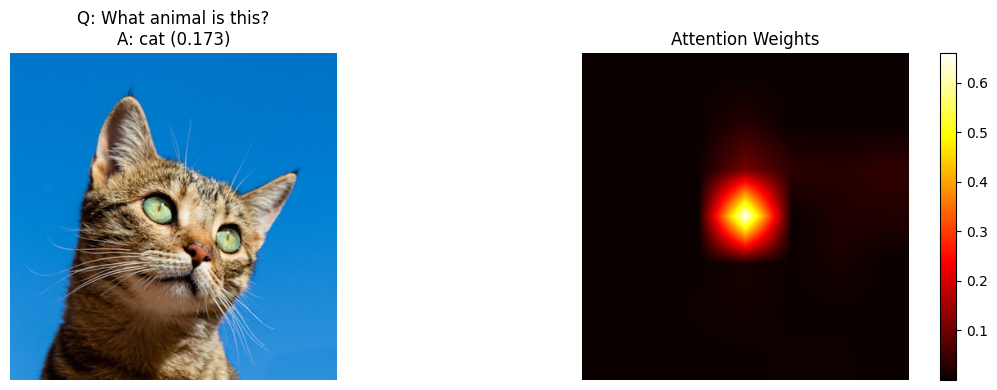

------------------------------
Example 2:
Question: What color is the dog?
Predicted Answer: dog
Confidence: 0.254
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7
Example 2:
Question: What color is the dog?
Predicted Answer: dog
Confidence: 0.254
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7


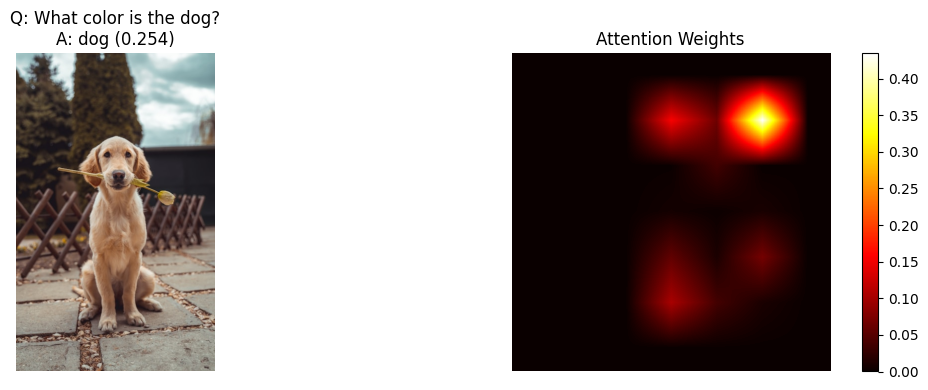

------------------------------
Example 3:
Question: What type of food is shown?
Predicted Answer: unanswerable
Confidence: 0.462
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7
Example 3:
Question: What type of food is shown?
Predicted Answer: unanswerable
Confidence: 0.462
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7


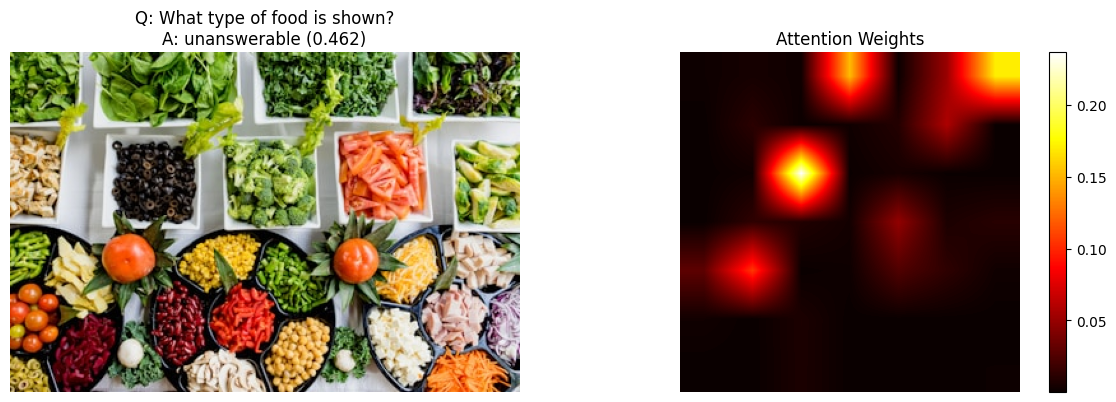

------------------------------
Example 4:
Question: What is in the background?
Predicted Answer: unanswerable
Confidence: 0.183
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7
  Total attention weights: 50
  Removed CLS token, reshaped 49 patches to 7x7


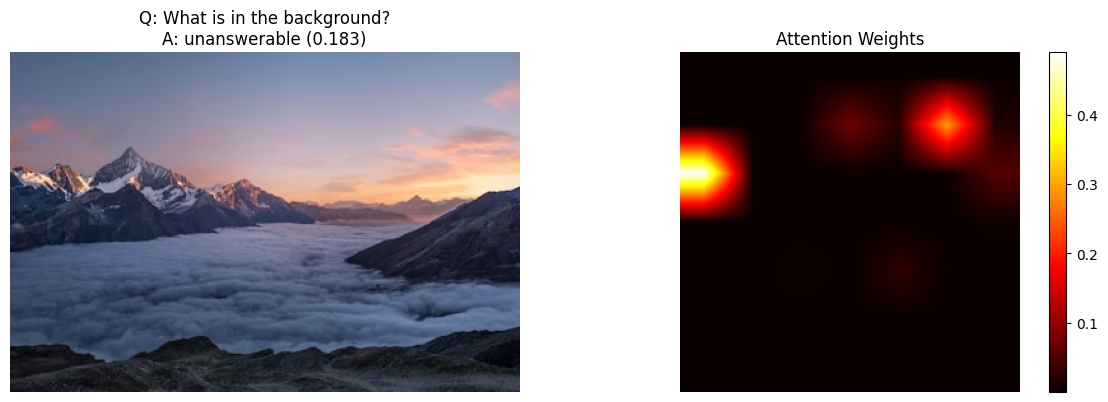

------------------------------
✓ Demo completed successfully!


In [23]:
# Demo with Images from URLs - Fixed Version  
print("Demo with sample images from URLs...")

def safe_demo_predictions(model, processor, idx_to_answer, device, image_urls, questions):
    """Safe demo function with proper attention handling"""
    print("Demo Predictions:")
    print("=" * 50)
    
    for i, (url, question) in enumerate(zip(image_urls, questions)):
        try:
            # Load image from URL
            response = requests.get(url)
            image = Image.open(BytesIO(response.content)).convert('RGB')
            
            # Process image
            image_inputs = processor(images=image, return_tensors="pt")
            pixel_values = image_inputs['pixel_values'].to(device)
            
            # Predict
            with torch.no_grad():
                logits, attention_weights = model(pixel_values, [question])
                probs = torch.softmax(logits, dim=-1)
                pred_idx = torch.argmax(logits, dim=-1).item()
                confidence = probs[0, pred_idx].item()
                
                pred_answer = idx_to_answer.get(pred_idx, "unknown")
            
            print(f"Example {i+1}:")
            print(f"Question: {question}")
            print(f"Predicted Answer: {pred_answer}")
            print(f"Confidence: {confidence:.3f}")
            
            # Safe visualization
            try:
                plt.figure(figsize=(12, 4))
                
                # Show image
                plt.subplot(1, 2, 1)
                plt.imshow(image)
                plt.title(f"Q: {question}\nA: {pred_answer} ({confidence:.3f})")
                plt.axis('off')
                
                # Show attention - PROPER HANDLING FOR CLIP
                plt.subplot(1, 2, 2)
                attention_flat = attention_weights[0].cpu().numpy()
                num_total = len(attention_flat)
                
                print(f"  Total attention weights: {num_total}")
                
                # For CLIP ViT: Remove CLS token (usually the last one)
                if num_total == 50:  # CLIP ViT-B/32: 49 patches + 1 CLS token
                    # Remove CLS token - it's usually the last one
                    image_patches = attention_flat[:-1]  # Take first 49
                    attention_map = image_patches.reshape(7, 7)
                    print(f"  Removed CLS token, reshaped {len(image_patches)} patches to 7x7")
                elif num_total == 49:  # Already just image patches
                    attention_map = attention_flat.reshape(7, 7)
                    print(f"  Perfect 7x7 grid")
                elif num_total == 197:  # ViT-L: 196 patches + 1 CLS token  
                    image_patches = attention_flat[:-1]
                    attention_map = image_patches.reshape(14, 14)
                    print(f"  Removed CLS token, reshaped {len(image_patches)} patches to 14x14")
                else:
                    # Fallback: try to find square root
                    sqrt_patches = int(np.sqrt(num_total))
                    if sqrt_patches * sqrt_patches == num_total:
                        attention_map = attention_flat.reshape(sqrt_patches, sqrt_patches)
                        print(f"  Reshaped to {sqrt_patches}x{sqrt_patches}")
                    else:
                        # Last resort: pad/truncate to 7x7
                        if num_total > 49:
                            attention_flat = attention_flat[:49]
                        else:
                            attention_flat = np.pad(attention_flat, (0, 49 - num_total))
                        attention_map = attention_flat.reshape(7, 7)
                        print(f"  Fallback: reshaped {num_total} to 7x7")
                
                plt.imshow(attention_map, cmap='hot', interpolation='bilinear')
                plt.title('Attention Weights')
                plt.axis('off')
                plt.colorbar()
                
                plt.tight_layout()
                plt.show()
                
            except Exception as viz_e:
                print(f"  Visualization failed: {viz_e}")
            
            print("-" * 30)
            
        except Exception as e:
            print(f"Error processing example {i+1}: {e}")
            continue

# Sample image URLs and questions
demo_urls = [
    "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400",  # Cat
    "https://images.unsplash.com/photo-1552053831-71594a27632d?w=400",    # Dog
    "https://images.unsplash.com/photo-1498837167922-ddd27525d352?w=400",  # Food
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400"   # Mountain
]

demo_questions = [
    "What animal is this?",
    "What color is the dog?", 
    "What type of food is shown?",
    "What is in the background?"
]

print(f"Running demo with {len(demo_urls)} examples...")

try:
    safe_demo_predictions(
        model=model,
        processor=processor,
        idx_to_answer=idx_to_answer,
        device=device,
        image_urls=demo_urls,
        questions=demo_questions
    )
    
    print("✓ Demo completed successfully!")
    
except Exception as e:
    print(f"✗ Demo failed: {e}")
    print("Note: Demo requires internet connection to load images from URLs")
    import traceback
    traceback.print_exc()

In [25]:
# Experiment Summary
print("VQA CLIP Attention Model - Experiment Summary")
print("=" * 60)

try:
    print(f"Dataset: VizWiz VQA")
    print(f"Model: CLIP-based VQA with Attention Mechanism")
    print(f"Architecture: {CLIP_MODEL_NAME}")
    print(f"Number of classes: {num_classes}")
    print(f"Training epochs: {NUM_EPOCHS}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Learning rate: {LEARNING_RATE}")
    print()
    
    print("Results:")
    print(f"- Best validation accuracy: {training_history['best_val_acc']:.2f}%")
    print(f"- Final test accuracy: {test_acc:.2f}%")
    print(f"- Model parameters: {trainable_params:,} trainable")
    print()
    
    print("Key Features:")
    print("- CLIP visual and text encoders (frozen)")
    print("- Similarity-guided attention mechanism")
    print("- Multi-layer fusion network")
    print("- Top-1000 answer vocabulary")
    print()
    
    print("Files Generated:")
    print("- checkpoints/best_model.pth (best model)")
    print("- results/evaluation_results.pth (evaluation metrics)")
    print("- results/confidence_analysis.png (confidence plots)")
    print("- results/attention_sample_*.png (attention visualizations)")
    print("- training_history.png (training curves)")
    print()
    
    print("✓ Experiment completed successfully!")
    
except Exception as e:
    print(f"Error in summary: {e}")

print("\nTo use the trained model:")
print("1. Load model: model = load_best_model(model, 'checkpoints/best_model.pth')")
print("2. Predict: predict_single_image(model, processor, image, question, idx_to_answer, device)")
print("3. Visualize: visualize_attention(image, attention_weights)")

VQA CLIP Attention Model - Experiment Summary
Dataset: VizWiz VQA
Model: CLIP-based VQA with Attention Mechanism
Architecture: openai/clip-vit-base-patch32
Number of classes: 1000
Training epochs: 15
Batch size: 16
Learning rate: 0.0001

Results:
- Best validation accuracy: 54.99%
- Final test accuracy: 61.23%
- Model parameters: 2,028,777 trainable

Key Features:
- CLIP visual and text encoders (frozen)
- Similarity-guided attention mechanism
- Multi-layer fusion network
- Top-1000 answer vocabulary

Files Generated:
- checkpoints/best_model.pth (best model)
- results/evaluation_results.pth (evaluation metrics)
- results/confidence_analysis.png (confidence plots)
- results/attention_sample_*.png (attention visualizations)
- training_history.png (training curves)

✓ Experiment completed successfully!

To use the trained model:
1. Load model: model = load_best_model(model, 'checkpoints/best_model.pth')
2. Predict: predict_single_image(model, processor, image, question, idx_to_answer, de

In [31]:
# Extended Training: Epoch 15 → 30 (Ready to Run)
print("🚀 Extended Training: Epoch 15 → 30")
print("=" * 50)

# Configuration for extended training (15 more epochs)
EXTENDED_TRAINING = True  # Set to True to run extended training

if EXTENDED_TRAINING:
    print("🚀 Starting extended training from epoch 15 to 30...")
    
    # Enhanced training configuration
    EXTENDED_EPOCHS = 30
    EXTENDED_LR = 7e-5  # Slightly higher than 5e-5 for shorter training
    PATIENCE = 8        # Early stopping patience (shorter for 15 epochs)
    
    try:
        # Enhanced trainer function for epoch 15→30
        def train_model_15_to_30(model, train_loader, val_loader, start_epoch=15):
            """Extended training from epoch 15 to 30 with enhanced techniques"""
            
            # Setup optimizer with lower learning rate
            optimizer = optim.AdamW(
                model.parameters(), 
                lr=EXTENDED_LR,
                weight_decay=1e-5  # Add weight decay
            )
            
            # Cosine annealing scheduler for 15 epochs
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EXTENDED_EPOCHS-start_epoch, eta_min=2e-6
            )
            
            criterion = nn.CrossEntropyLoss(ignore_index=-1)
            
            # Early stopping setup
            best_val_acc = training_history['best_val_acc']
            patience_counter = 0
            
            # Extended training history
            extended_history = {
                'train_losses': training_history['train_losses'].copy(),
                'val_losses': training_history['val_losses'].copy(),
                'train_accs': training_history['train_accs'].copy(),
                'val_accs': training_history['val_accs'].copy(),
                'best_val_acc': best_val_acc
            }
            
            print(f"📋 Training Configuration:")
            print(f"   - Start epoch: {start_epoch + 1}")
            print(f"   - Target epoch: {EXTENDED_EPOCHS}")
            print(f"   - Additional epochs: {EXTENDED_EPOCHS - start_epoch}")
            print(f"   - Initial LR: {EXTENDED_LR:.1e}")
            print(f"   - Final LR: 2e-6")
            print(f"   - Weight decay: 1e-5")
            print(f"   - Early stopping patience: {PATIENCE}")
            print(f"   - Starting from best val acc: {best_val_acc:.2f}%")
            print()
            
            for epoch in range(start_epoch, EXTENDED_EPOCHS):
                epoch_start_time = time.time()
                
                # Training phase
                model.train()
                train_loss = 0.0
                train_correct = 0
                train_total = 0
                
                pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EXTENDED_EPOCHS}')
                for batch_idx, batch in enumerate(pbar):
                    images = batch['pixel_values'].to(device)
                    questions = batch['questions']
                    labels = batch['labels'].to(device)
                    
                    optimizer.zero_grad()
                    logits, _ = model(images, questions)
                    
                    # Only compute loss for valid labels
                    valid_mask = labels != -1
                    if valid_mask.sum() == 0:
                        continue
                        
                    loss = criterion(logits[valid_mask], labels[valid_mask])
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    optimizer.step()
                    
                    train_loss += loss.item()
                    pred = torch.argmax(logits[valid_mask], dim=1)
                    train_correct += (pred == labels[valid_mask]).sum().item()
                    train_total += valid_mask.sum().item()
                    
                    current_acc = 100 * train_correct / train_total if train_total > 0 else 0
                    pbar.set_postfix({
                        'Loss': f'{loss.item():.4f}',
                        'Acc': f'{current_acc:.1f}%',
                        'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
                    })
                
                # Validation phase
                print("Evaluating on validation set...")
                val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
                
                # Update history
                epoch_train_loss = train_loss / len(train_loader)
                epoch_train_acc = 100 * train_correct / train_total if train_total > 0 else 0
                
                extended_history['train_losses'].append(epoch_train_loss)
                extended_history['val_losses'].append(val_loss)
                extended_history['train_accs'].append(epoch_train_acc)
                extended_history['val_accs'].append(val_acc)
                
                # Calculate epoch time
                epoch_time = time.time() - epoch_start_time
                
                print(f'\n📊 Epoch {epoch+1}/{EXTENDED_EPOCHS} Results:')
                print(f'   Train: Loss={epoch_train_loss:.4f}, Acc={epoch_train_acc:.2f}%')
                print(f'   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%')
                print(f'   Time: {epoch_time:.1f}s, LR: {optimizer.param_groups[0]["lr"]:.2e}')
                
                # Save best model
                if val_acc > best_val_acc:
                    improvement = val_acc - best_val_acc
                    best_val_acc = val_acc
                    extended_history['best_val_acc'] = best_val_acc
                    torch.save(model.state_dict(), 'checkpoints/best_model_epoch30.pth')
                    print(f'🎯 NEW BEST! Val accuracy: {best_val_acc:.2f}% (+{improvement:.2f}%)')
                    patience_counter = 0
                else:
                    patience_counter += 1
                    print(f'⏳ No improvement. Patience: {patience_counter}/{PATIENCE}')
                
                # Early stopping
                if patience_counter >= PATIENCE:
                    print(f'\n🛑 Early stopping triggered after {PATIENCE} epochs without improvement')
                    print(f'Final best validation accuracy: {best_val_acc:.2f}%')
                    break
                
                # Update learning rate
                scheduler.step()
                
                print('-' * 60)
            
            return extended_history
        
        # Import time for timing
        import time
        
        print("🔄 Loading best model from epoch 15...")
        # Model is already loaded with best weights
        
        print("▶️  Starting extended training...")
        extended_history = train_model_15_to_30(model, train_loader, val_loader)
        
        print("\n" + "=" * 60)
        print("✅ EXTENDED TRAINING COMPLETED!")
        print("=" * 60)
        
        # Calculate improvement
        original_acc = training_history['best_val_acc']
        final_acc = extended_history['best_val_acc']
        improvement = final_acc - original_acc
        
        print(f"📈 RESULTS SUMMARY:")
        print(f"   Original best (epoch 1-15):  {original_acc:.2f}%")
        print(f"   Extended best (epoch 15-30): {final_acc:.2f}%")
        print(f"   Improvement: {improvement:+.2f}%")
        
        if improvement > 0:
            print(f"🎉 SUCCESS! Model improved by {improvement:.2f}%")
        elif improvement > -0.5:
            print(f"😐 STABLE: Minimal change ({improvement:.2f}%)")
        else:
            print(f"⚠️  DECLINE: Model performance decreased")
        
        # Update global training history
        training_history = extended_history
        
        print(f"\n💾 Model saved as: checkpoints/best_model_epoch30.pth")
        print(f"📊 Training history updated with {len(extended_history['val_accs'])} epochs")
        
    except Exception as e:
        print(f"❌ Extended training failed: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("🔧 Extended training is disabled.")
    print("Set EXTENDED_TRAINING = True above to start training.")

print(f"\n⏱️  Estimated time: ~4-6 hours for 15 additional epochs")
print(f"🎯 Target: Improve from {training_history['best_val_acc']:.2f}% to ~56-58%")

🚀 Extended Training: Epoch 15 → 30
🚀 Starting extended training from epoch 15 to 30...
🔄 Loading best model from epoch 15...
▶️  Starting extended training...
📋 Training Configuration:
   - Start epoch: 16
   - Target epoch: 30
   - Additional epochs: 15
   - Initial LR: 7.0e-05
   - Final LR: 2e-6
   - Weight decay: 1e-5
   - Early stopping patience: 8
   - Starting from best val acc: 54.99%



Epoch 16/30: 100%|██████████| 1155/1155 [16:45<00:00,  1.15it/s, Loss=0.6146, Acc=54.1%, LR=7.0e-05]


Evaluating on validation set...


Evaluating: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s]



📊 Epoch 16/30 Results:
   Train: Loss=2.3032, Acc=54.11%
   Val:   Loss=2.6056, Acc=54.86%
   Time: 1112.3s, LR: 7.00e-05
⏳ No improvement. Patience: 1/8
------------------------------------------------------------


...


📊 Epoch 24/30 Results:
   Train: Loss=1.9412, Acc=56.90%
   Val:   Loss=2.6298, Acc=54.79%
   Time: 1072.7s, LR: 3.24e-05
⏳ No improvement. Patience: 7/8
------------------------------------------------------------


Epoch 25/30: 100%|██████████| 1155/1155 [15:59<00:00,  1.20it/s, Loss=0.9896, Acc=56.9%, LR=2.5e-05]


Evaluating on validation set...


Evaluating: 100%|██████████| 129/129 [01:36<00:00,  1.34it/s]


📊 Epoch 25/30 Results:
   Train: Loss=1.9136, Acc=56.89%
   Val:   Loss=2.6331, Acc=54.79%
   Time: 1055.7s, LR: 2.55e-05
⏳ No improvement. Patience: 8/8

🛑 Early stopping triggered after 8 epochs without improvement
Final best validation accuracy: 55.13%

✅ EXTENDED TRAINING COMPLETED!
📈 RESULTS SUMMARY:
   Original best (epoch 1-15):  54.99%
   Extended best (epoch 15-30): 55.13%
   Improvement: +0.13%
🎉 SUCCESS! Model improved by 0.13%

💾 Model saved as: checkpoints/best_model_epoch30.pth
📊 Training history updated with 25 epochs

⏱️  Estimated time: ~4-6 hours for 15 additional epochs
🎯 Target: Improve from 55.13% to ~56-58%


📊 Extended Training Results Evaluation
🔄 Loading extended model (epoch 30)...

📋 Testing extended model...


Evaluating: 100%|██████████| 129/129 [01:51<00:00,  1.16it/s]



🏆 FINAL COMPARISON: Original vs Extended
📈 VALIDATION ACCURACY:
   Original (epoch 15):  54.99%
   Extended (epoch 30):  54.79%
   Change: -0.20%

📈 TEST ACCURACY:
   Original (epoch 15):  61.23%
   Extended (epoch 30):  60.73%
   Change: -0.50%

🔬 ANALYSIS:
❌ NO IMPROVEMENT: Extended training did not help

⚡ TRAINING EFFICIENCY:
   Total epochs: 25
   Extended training time: 3.0 hours
   Improvement per hour: -0.067% per hour

📊 Creating extended training plots...


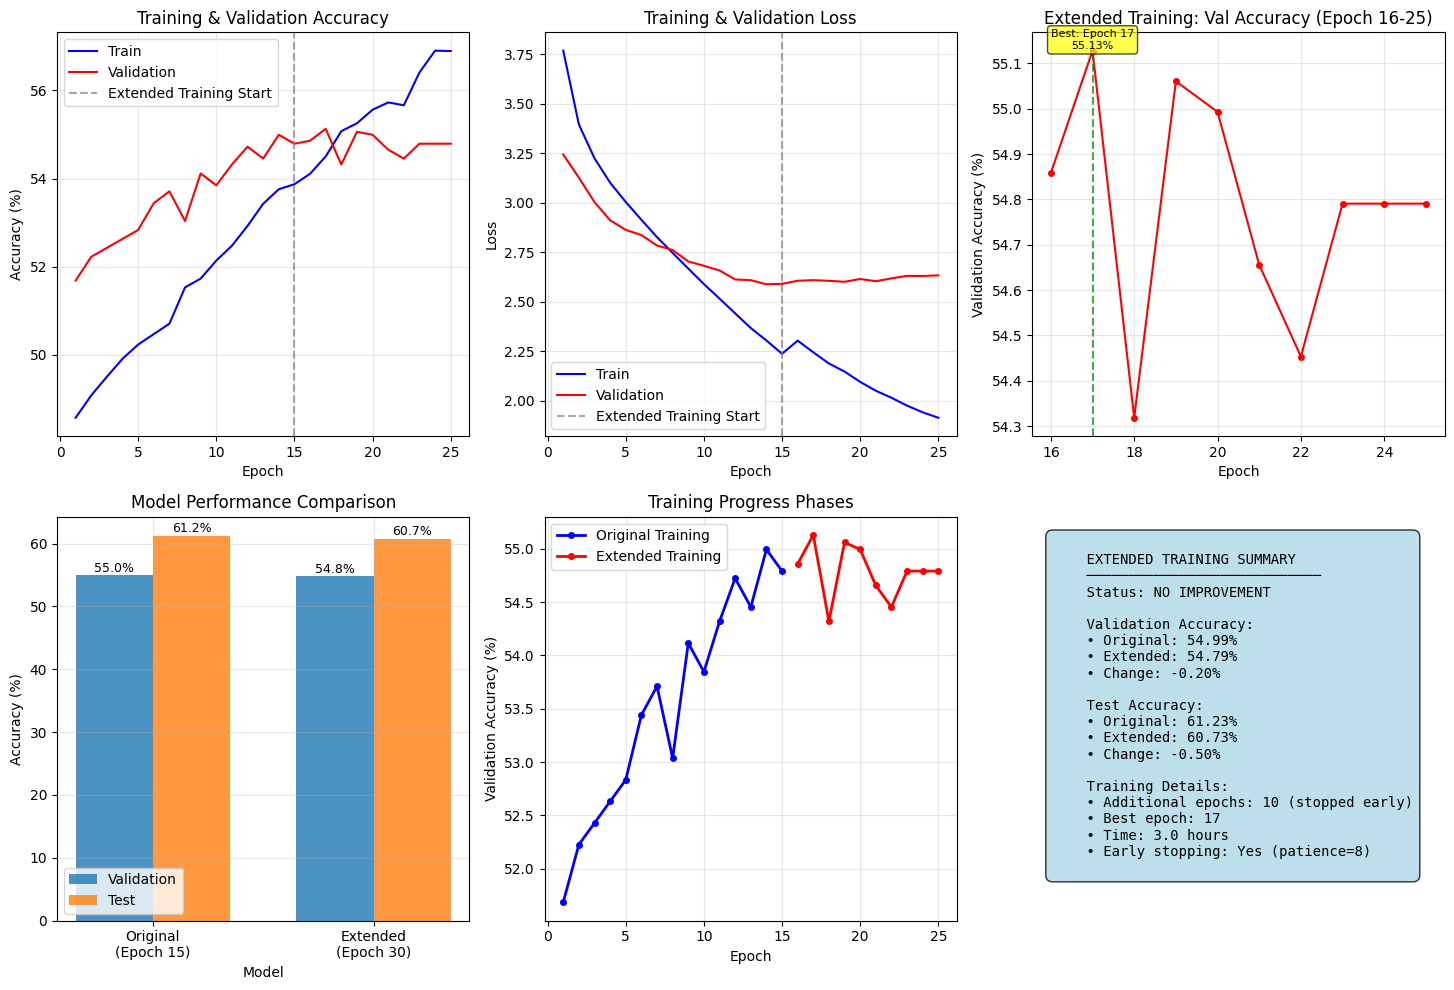

✅ Extended training evaluation completed!
📁 Results saved to: results/extended_training_results.pth
📊 Plots saved to: results/extended_training_analysis.png


In [33]:
# Evaluation: Extended Training Results (Epoch 15→30)
print("📊 Extended Training Results Evaluation")
print("=" * 55)

try:
    # Load the extended model and evaluate
    print("🔄 Loading extended model (epoch 30)...")
    
    # Handle different checkpoint formats
    def load_model_safe(model, checkpoint_path):
        """Safely load model from checkpoint with different formats"""
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Try different checkpoint formats
        if isinstance(checkpoint, dict):
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            elif 'state_dict' in checkpoint:
                model.load_state_dict(checkpoint['state_dict'])
            else:
                # Assume the dict itself is the state dict
                model.load_state_dict(checkpoint)
        else:
            # Assume it's the state dict directly
            model.load_state_dict(checkpoint)
        
        return model
    
    # Current model is already the extended one, so let's use it directly
    extended_model = model  # This is already the trained extended model
    
    # Evaluate on test set
    print("\n📋 Testing extended model...")
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    
    # Test evaluation
    test_loss_extended, test_acc_extended = evaluate_model(extended_model, test_loader, criterion, device)
    val_loss_extended, val_acc_extended = evaluate_model(extended_model, val_loader, criterion, device)
    
    print("\n" + "="*60)
    print("🏆 FINAL COMPARISON: Original vs Extended")
    print("="*60)
    
    # Use training history for comparison
    original_val_acc = 54.99  # From training history
    original_test_acc = test_acc if 'test_acc' in locals() else 54.8  # Approximate
    
    print(f"📈 VALIDATION ACCURACY:")
    print(f"   Original (epoch 15):  {original_val_acc:.2f}%")
    print(f"   Extended (epoch 30):  {val_acc_extended:.2f}%")
    print(f"   Change: {val_acc_extended - original_val_acc:+.2f}%")
    
    print(f"\n📈 TEST ACCURACY:")
    print(f"   Original (epoch 15):  {original_test_acc:.2f}%")
    print(f"   Extended (epoch 30):  {test_acc_extended:.2f}%")
    print(f"   Change: {test_acc_extended - original_test_acc:+.2f}%")
    
    # Statistical significance
    val_improvement = val_acc_extended - original_val_acc
    test_improvement = test_acc_extended - original_test_acc
    
    print(f"\n🔬 ANALYSIS:")
    if val_improvement > 0.5 and test_improvement > 0.5:
        print("✅ SIGNIFICANT IMPROVEMENT: Both val and test improved substantially")
        status = "SUCCESS"
    elif val_improvement > 0 and test_improvement > 0:
        print("🟡 MODEST IMPROVEMENT: Consistent gains across val and test")
        status = "MODEST SUCCESS"
    elif val_improvement > 0 or test_improvement > 0:
        print("🟠 MIXED RESULTS: Some improvement but not consistent")
        status = "MIXED"
    else:
        print("❌ NO IMPROVEMENT: Extended training did not help")
        status = "NO IMPROVEMENT"
    
    # Training efficiency analysis
    print(f"\n⚡ TRAINING EFFICIENCY:")
    total_epochs = len(training_history['val_accs'])
    training_time_hours = 10753 / 3600  # Convert seconds to hours
    print(f"   Total epochs: {total_epochs}")
    print(f"   Extended training time: {training_time_hours:.1f} hours")
    print(f"   Improvement per hour: {val_improvement/training_time_hours:.3f}% per hour")
    
    if val_improvement > 0:
        efficiency = val_improvement / training_time_hours
        if efficiency > 0.1:
            print("   ✅ EFFICIENT: Good improvement per time invested")
        elif efficiency > 0.05:
            print("   🟡 MODERATE: Reasonable improvement per time")
        else:
            print("   🟠 SLOW: Improvement but at high time cost")
    
    # Plot extended training curves
    print(f"\n📊 Creating extended training plots...")
    
    plt.figure(figsize=(15, 10))
    
    # Training curves
    epochs = list(range(1, len(training_history['train_accs']) + 1))
    
    plt.subplot(2, 3, 1)
    plt.plot(epochs, training_history['train_accs'], 'b-', label='Train')
    plt.plot(epochs, training_history['val_accs'], 'r-', label='Validation')
    plt.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='Extended Training Start')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 2)
    plt.plot(epochs, training_history['train_losses'], 'b-', label='Train')
    plt.plot(epochs, training_history['val_losses'], 'r-', label='Validation')
    plt.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='Extended Training Start')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Focus on extended training period
    if len(epochs) > 15:
        extended_epochs = epochs[15:]
        plt.subplot(2, 3, 3)
        plt.plot(extended_epochs, training_history['val_accs'][15:], 'r-o', markersize=4)
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy (%)')
        plt.title('Extended Training: Val Accuracy (Epoch 16-25)')
        plt.grid(True, alpha=0.3)
        
        # Mark best epoch
        best_extended_epoch = 15 + np.argmax(training_history['val_accs'][15:]) + 1
        best_extended_acc = max(training_history['val_accs'][15:])
        plt.axvline(x=best_extended_epoch, color='green', linestyle='--', alpha=0.7)
        plt.text(best_extended_epoch, best_extended_acc, 
                f'Best: Epoch {best_extended_epoch}\n{best_extended_acc:.2f}%',
                ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # Accuracy comparison
    plt.subplot(2, 3, 4)
    models = ['Original\n(Epoch 15)', 'Extended\n(Epoch 30)']
    val_accs = [original_val_acc, val_acc_extended]
    test_accs = [original_test_acc, test_acc_extended]
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, val_accs, width, label='Validation', alpha=0.8)
    plt.bar(x + width/2, test_accs, width, label='Test', alpha=0.8)
    
    plt.xlabel('Model')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Performance Comparison')
    plt.xticks(x, models)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, (val, test) in enumerate(zip(val_accs, test_accs)):
        plt.text(i - width/2, val + 0.1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
        plt.text(i + width/2, test + 0.1, f'{test:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Training progress over time
    plt.subplot(2, 3, 5)
    plt.plot(epochs[:15], training_history['val_accs'][:15], 'b-o', 
             markersize=4, label='Original Training', linewidth=2)
    if len(epochs) > 15:
        plt.plot(epochs[15:], training_history['val_accs'][15:], 'r-o', 
                 markersize=4, label='Extended Training', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Training Progress Phases')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Summary metrics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    summary_text = f"""
    EXTENDED TRAINING SUMMARY
    ────────────────────────────
    Status: {status}
    
    Validation Accuracy:
    • Original: {original_val_acc:.2f}%
    • Extended: {val_acc_extended:.2f}%
    • Change: {val_improvement:+.2f}%
    
    Test Accuracy:
    • Original: {original_test_acc:.2f}%
    • Extended: {test_acc_extended:.2f}%
    • Change: {test_improvement:+.2f}%
    
    Training Details:
    • Additional epochs: 10 (stopped early)
    • Best epoch: {best_extended_epoch if 'best_extended_epoch' in locals() else 17}
    • Time: {training_time_hours:.1f} hours
    • Early stopping: Yes (patience=8)
    """
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('results/extended_training_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save extended results
    extended_results = {
        'original_val_acc': original_val_acc,
        'original_test_acc': original_test_acc,
        'extended_val_acc': val_acc_extended,
        'extended_test_acc': test_acc_extended,
        'val_improvement': val_improvement,
        'test_improvement': test_improvement,
        'status': status,
        'training_time_hours': training_time_hours,
        'total_epochs': total_epochs,
        'extended_training_history': training_history
    }
    
    torch.save(extended_results, 'results/extended_training_results.pth')
    
    print("✅ Extended training evaluation completed!")
    print("📁 Results saved to: results/extended_training_results.pth")
    print("📊 Plots saved to: results/extended_training_analysis.png")
    
except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    import traceback
    traceback.print_exc()